# APS1: EDA

Realizando importações necessarias para o projeto

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score

## 1. Carregamento e inspeção inicial dos dados ##

Explicando cada feature e identificando os tipos de dados do dataset

- `age`:    **Idade do indivíduo** (contínua);
- `workclass`:  **Categoria do trabalho** (categórica);
- `fnlwgt`:     **Peso final** (contínua);
- `education`:  **Nível de escolaridade** (categórica);
- `education-num`:  **Nível de escolaridade em grau** (contínua);
- `marital-status`:     **Estado civil** (categórica);
- `occupation`:     **Ocupação profissional** (categórica);
- `relationship`:   **Relacionamento** (categórica);
- `race`:   **Etnia** (categórica);
- `sex`:    **Gênero** (categórica);
- `capital-gain`:   **Ganhos de capital** (contínua);
- `capital-loss`:   **Perdas de capital** (contínua);
- `hours-per-week`:     **Horas de trabalho semanais** (contínua);
- `native-country`:     **País de origem** (categórica);
- `income`:     **Renda anual** (contínua);

Carregamento e analise dos datasets:
- Conjunto de treino: `adult.data`

In [2]:
# Carregando o dataset adult.data
df_train = pd.read_csv('dataset/adult.data', header=None)
df_train.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
              'income']
df_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


- Conjunto de teste: `adult.test`

In [3]:
# Carregando o dataset adult.test
df_test = pd.read_csv('dataset/adult.test', header=None, skiprows=1)
df_test.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
              'income']
# df_test.head()

Verificando o número de instâncias e features

In [4]:
df_train.shape, df_test.shape

((32561, 15), (16281, 15))

In [5]:
df_train.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

Dentro do dataset de treino possuimos **32561** instâncias e **14** features (e 1 target)

Separacao Treino/Teste

In [6]:
# selecao de features e target
features = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

# Criação das matrize de features e vetor de target
X = df_train[features]
y = df_train['income']

# separacao dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Inspecionando o conjunto de treino e teste

In [7]:
X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
5514,33,Local-gov,198183,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,50,United-States
19777,36,Private,86459,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1887,50,United-States
10781,58,Self-emp-not-inc,203039,9th,5,Separated,Craft-repair,Not-in-family,White,Male,0,0,40,United-States
32240,21,Private,180190,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,46,United-States
9876,27,Private,279872,Some-college,10,Divorced,Other-service,Not-in-family,White,Male,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States
5390,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,0,21,United-States
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,20,United-States
15795,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,84,United-States


In [8]:
y_train

5514       >50K
19777      >50K
10781     <=50K
32240     <=50K
9876      <=50K
          ...  
29802     <=50K
5390      <=50K
860       <=50K
15795     <=50K
23654     <=50K
Name: income, Length: 26048, dtype: str

Detecção de valores ausentes ('?') e inconsistênias.

In [9]:
# remover espaços em branco antes do '?'
df_train.replace(' ?', '?', inplace=True)
missing_counts = df_train.isin(['?']).sum()

print("=====================================")
print("Contagem de '?' por coluna no treino:")
print("=====================================")
print(missing_counts)

Contagem de '?' por coluna no treino:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


Dentro do nosso dataset de treino as features: `workclass`, `occupation` e `native_country` possuem dados faltantes.

Alem disso, as colunas `education` e `education-num` são redundantes, pois representam os mesmos dados.

<Axes: xlabel='age', ylabel='Count'>

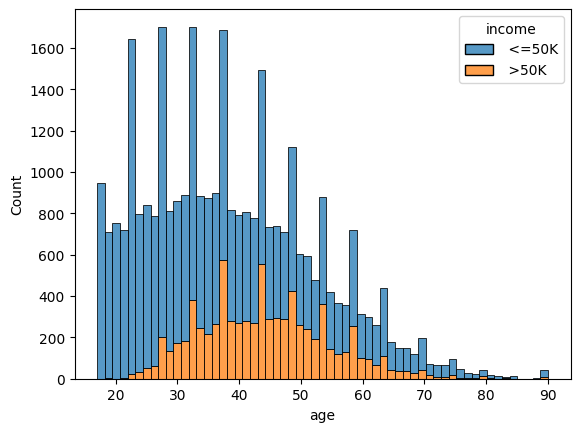

In [10]:
sns.histplot(data=df_train, x='age', hue='income', multiple='stack')

## 2. Análise univariada ##

**Medidas descritivas para variáveis contínuas.**

In [44]:
numericals = ['age', 'fnlwgt', 'capital-gain', 'education-num', 'capital-loss', 'hours-per-week']
X_train[numericals].describe()

,age,fnlwgt,capital-gain,education-num,capital-loss,hours-per-week
count,26048.000000,2.604800e+04,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.576513,1.897592e+05,1053.617437,10.080544,87.988828,40.388552
std,13.642904,1.052329e+05,7230.800656,2.575202,403.629787,12.331139
min,17.000000,1.228500e+04,0.000000,1.000000,0.000000,1.000000
25%,28.000000,1.179630e+05,0.000000,9.000000,0.000000,40.000000
50%,37.000000,1.782635e+05,0.000000,10.000000,0.000000,40.000000
75%,48.000000,2.370065e+05,0.000000,12.000000,0.000000,45.000000
max,90.000000,1.484705e+06,99999.000000,16.000000,4356.000000,99.000000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>,
        <Axes: title={'center': 'capital-gain'}>],
       [<Axes: title={'center': 'education-num'}>,
        <Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>]], dtype=object)

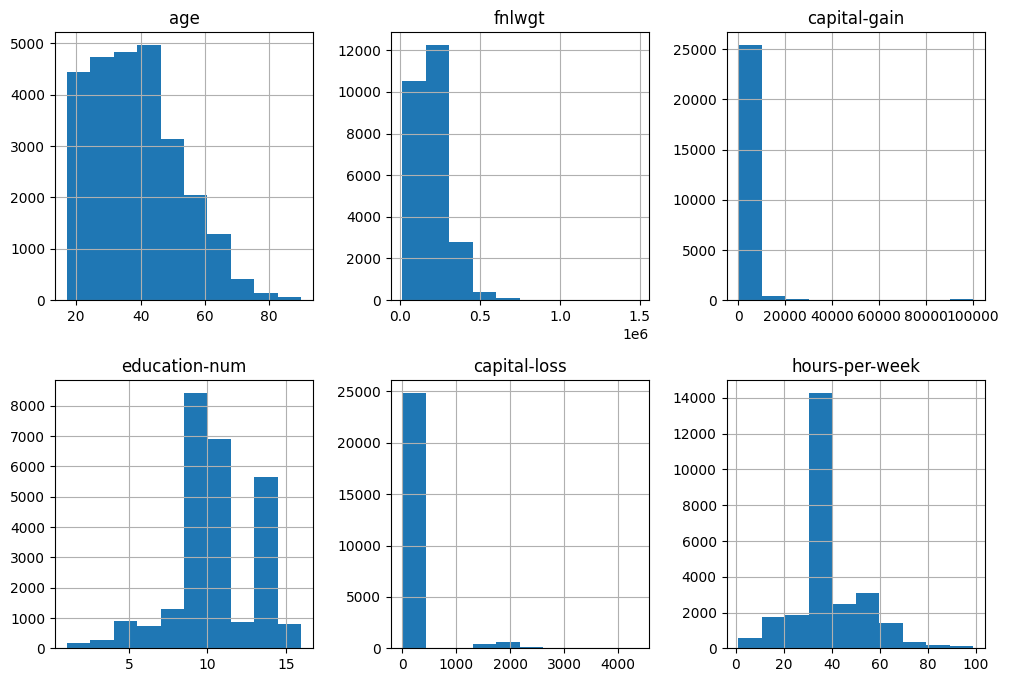

In [45]:
X_train[numericals].hist(layout=(2, 3), figsize=(12, 8))

**Medidas descritivas para variáveis categóricas.**

       workclass education       marital-status       occupation relationship  \
count      26048     26048                26048            26048        26048   
unique         9        16                    7               15            6   
top      Private   HS-grad   Married-civ-spouse   Prof-specialty      Husband   
freq       18118      8416                12026             3312        10603   

          race    sex  native-country  
count    26048  26048           26048  
unique       5      2              42  
top      White   Male   United-States  
freq     22221  17403           23300  

                                                         Frequency
workclass    education     marital-status      occupation         relationship    race   sex     native-country
Private      HS-grad       Married-civ-spouse  Craft-repair       Husband         White  Male    United-States     656
             Bachelors     Married-civ-spouse  Exec-managerial    Husband         White  Male  

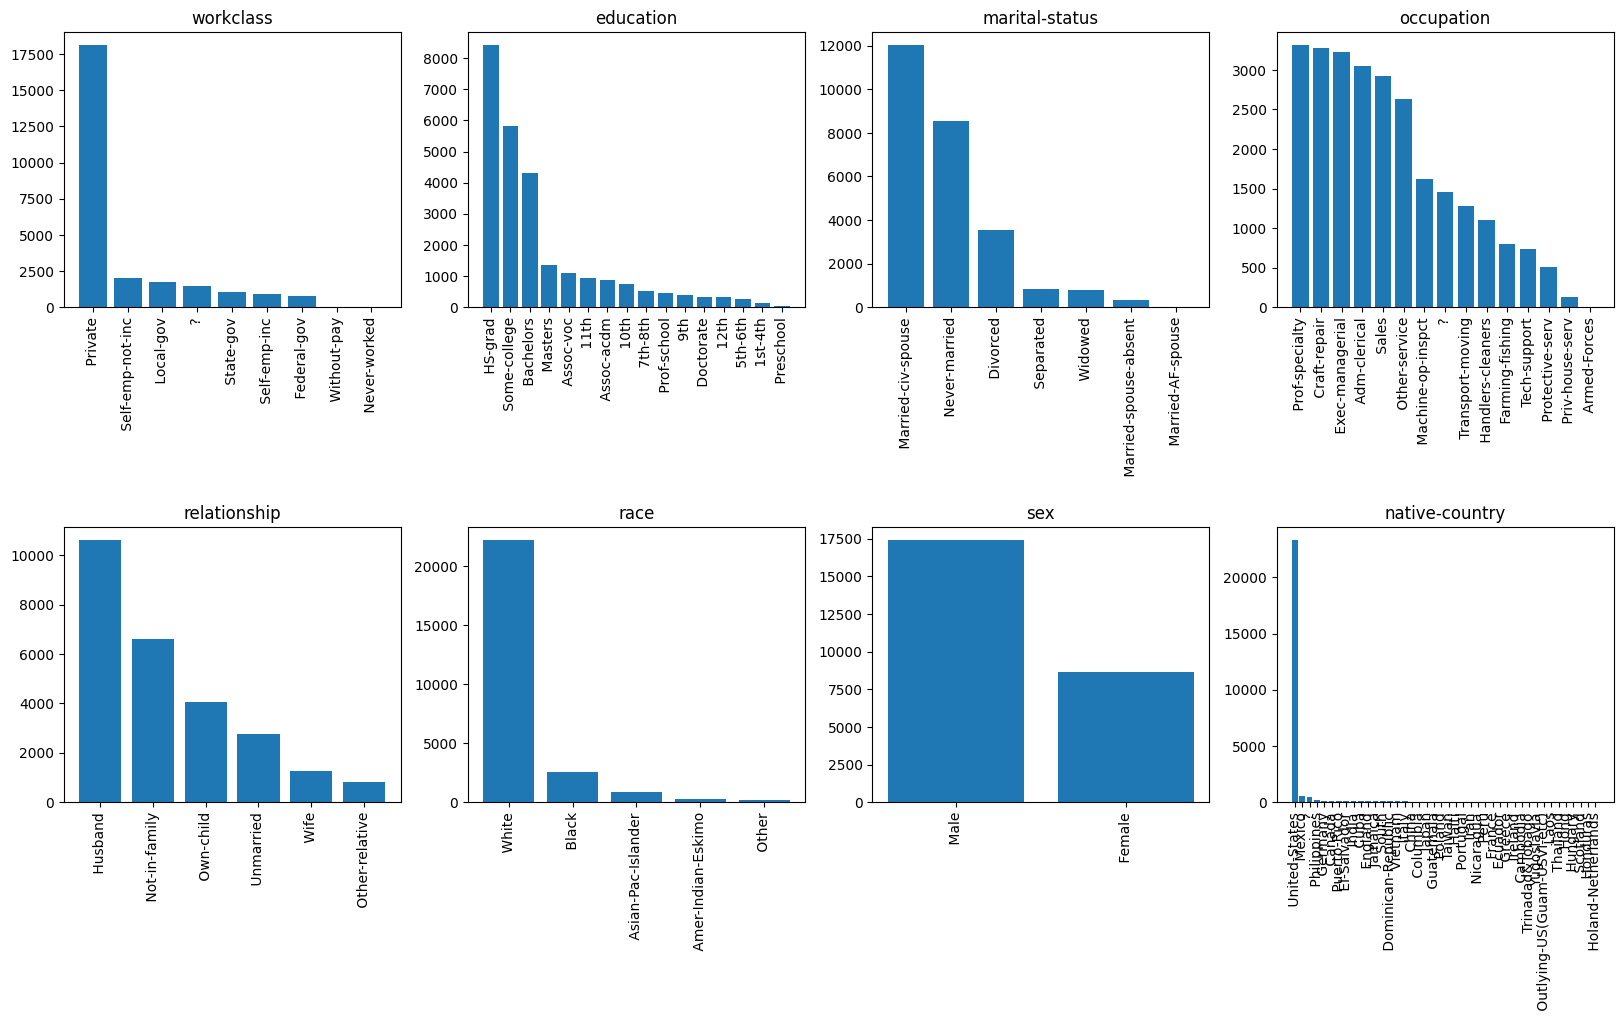

In [41]:
categories = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
print("===================================================================================================================================")
print(X_train[categories].describe())
print("\n===================================================================================================================================")
print("                                                         Frequency")
print("===================================================================================================================================")
print(X_train[categories].value_counts())

# Visualização das distribuições das variáveis categóricas
i = 1
plt.figure(figsize=(20, 10))
for col in categories:
    plt.subplot(2, 4, i)
    plt.bar(X_train[col].value_counts().index.astype(str), X_train[col].value_counts().values)
    plt.title(col)
    plt.xticks(rotation=90)
    i += 1
plt.subplots_adjust(hspace=0.8)
plt.show()

**Detecção de outliers nas variaveis númericas**

age                  Axes(0.125,0.53;0.168478x0.35)
fnlwgt            Axes(0.327174,0.53;0.168478x0.35)
capital-gain      Axes(0.529348,0.53;0.168478x0.35)
education-num     Axes(0.731522,0.53;0.168478x0.35)
capital-loss         Axes(0.125,0.11;0.168478x0.35)
hours-per-week    Axes(0.327174,0.11;0.168478x0.35)
dtype: object

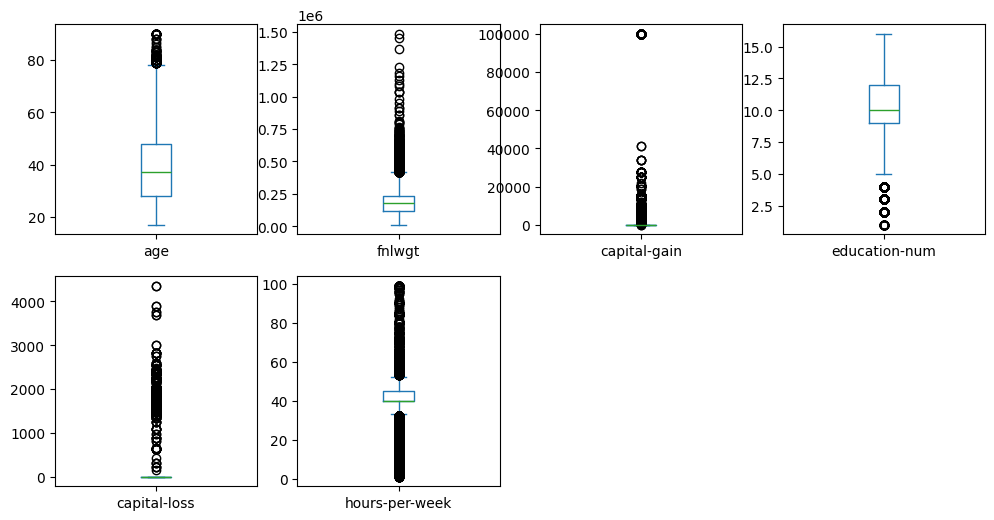

In [47]:
X_train[numericals].plot(kind='box', subplots=True, layout=(2, 4), figsize=(12, 6), sharey=False)

## 3. Análise bivariada e multivariada ##

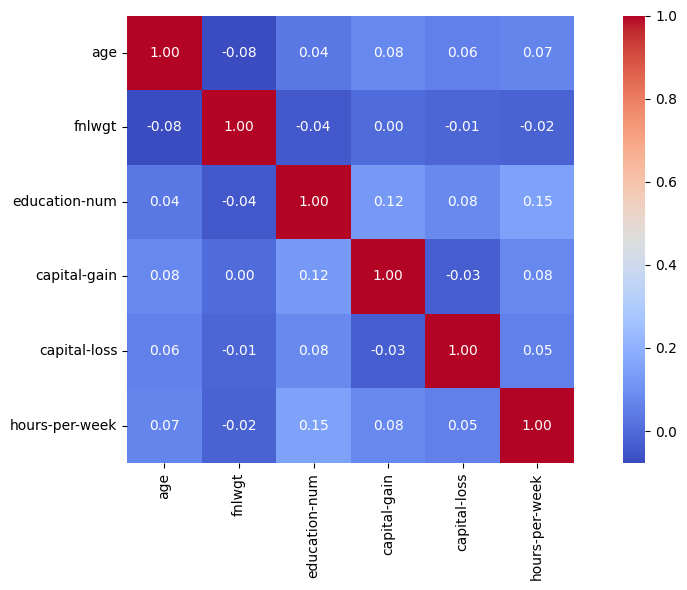

In [48]:
df_train.dtypes

numeric_cols = df_train.select_dtypes(include=['int64'])
corr_matrix = numeric_cols.corr()
# plotando o  heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, fmt='.2f', square=True, linecolor='white', annot=True, cmap="coolwarm");
plt.tight_layout()

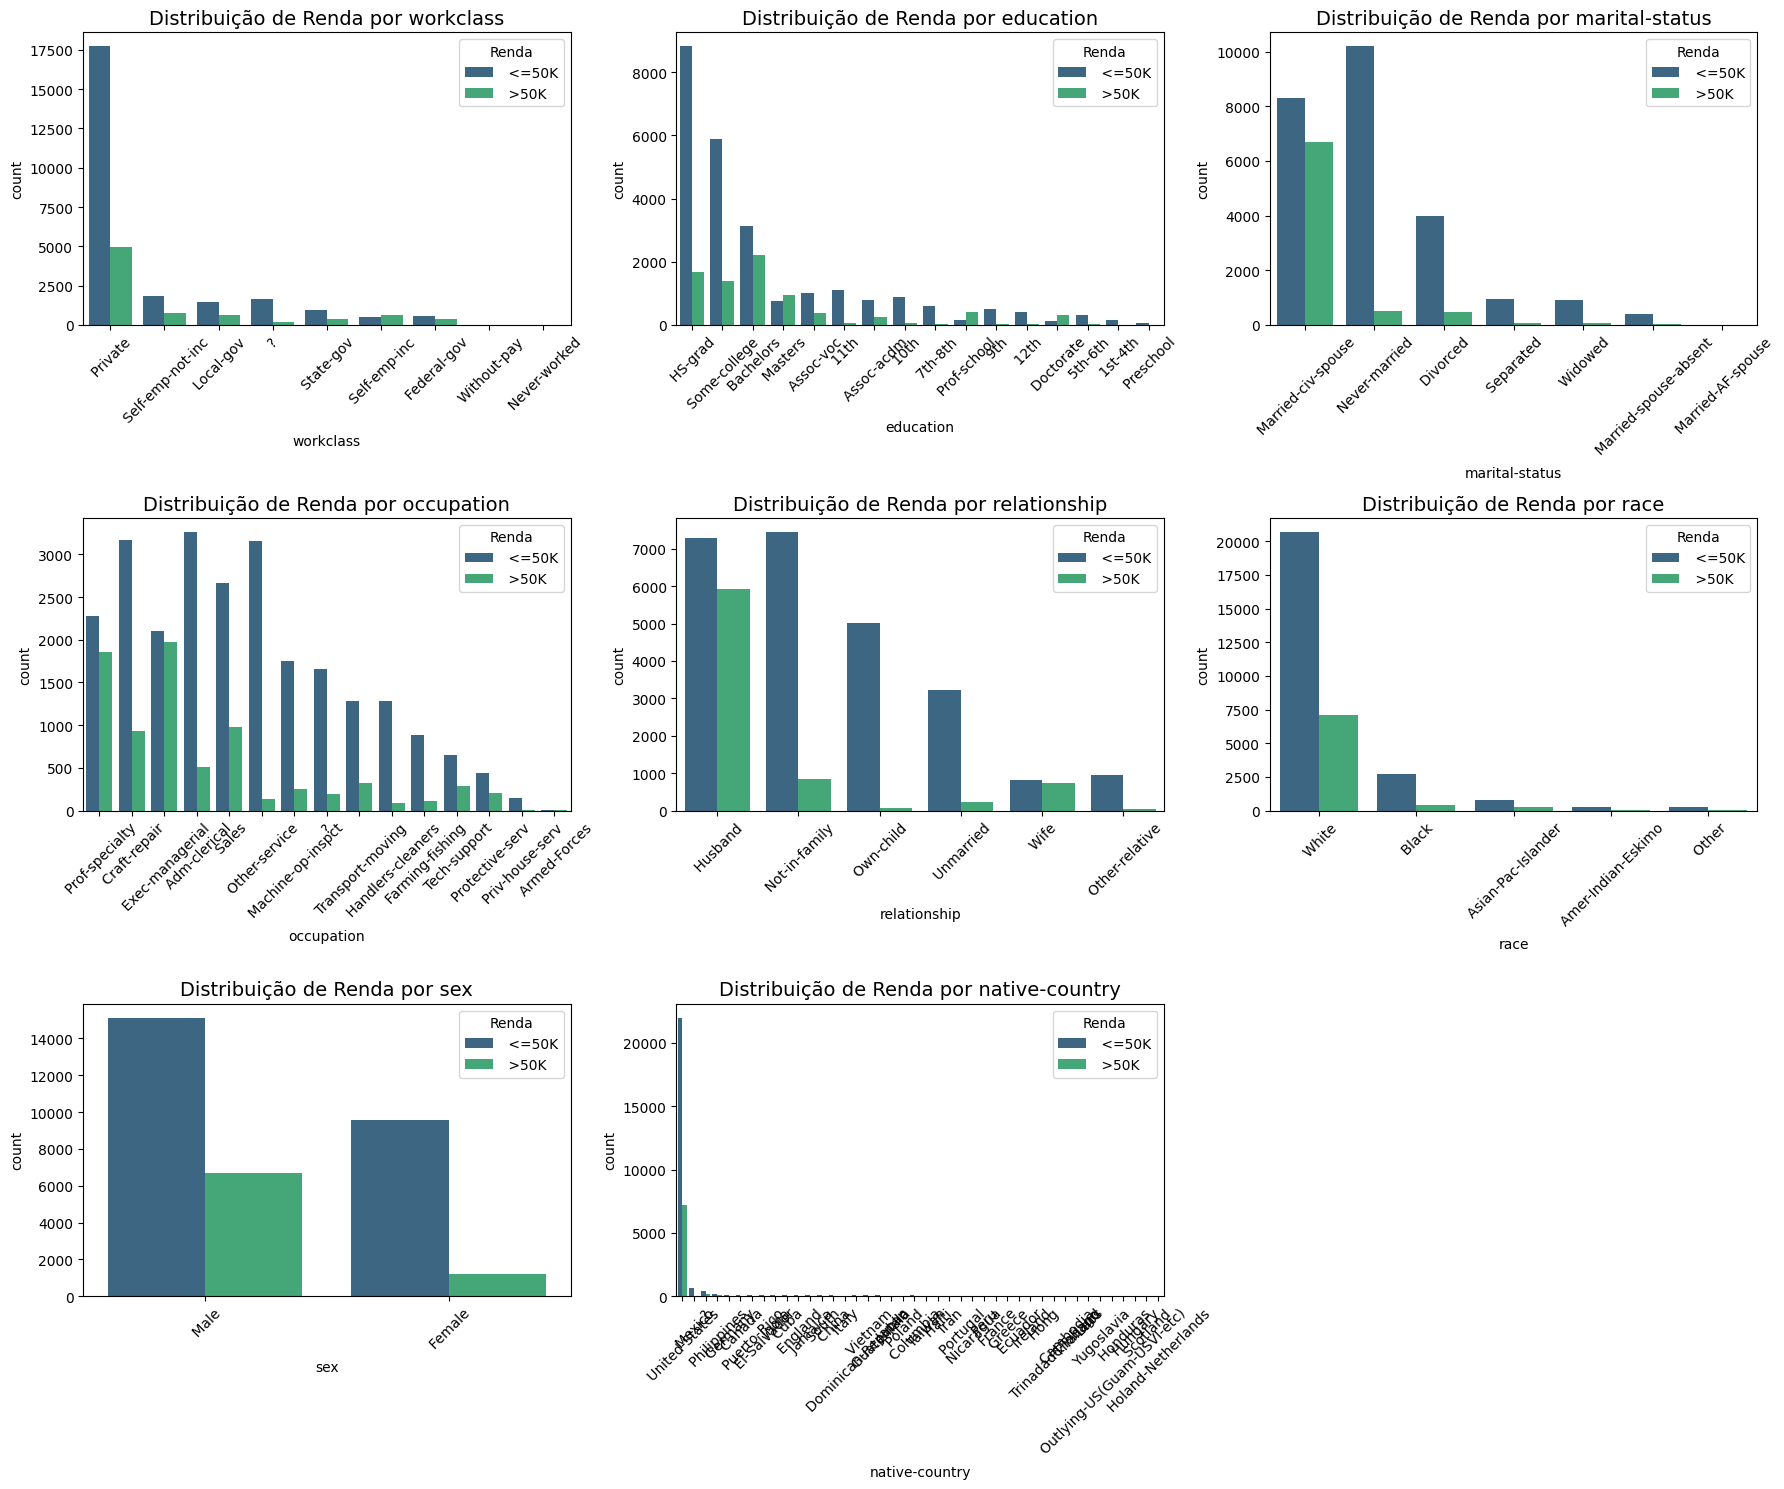

In [ ]:
cat_to_analyze = ['workclass', 'education', 'marital-status', 'occupation', 
                  'relationship', 'race', 'sex', 'native-country']

cols = 3 #======================================================== se quiser mudar
rows = (len(cat_to_analyze) + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_to_analyze):
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, hue='income', ax=axes[i], palette='viridis', order=order)
    
    axes[i].set_title(f'Distribuição de Renda por {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Renda', loc='upper right')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


--- Analisando Variáveis Numéricas para a Categoria: SEX ---


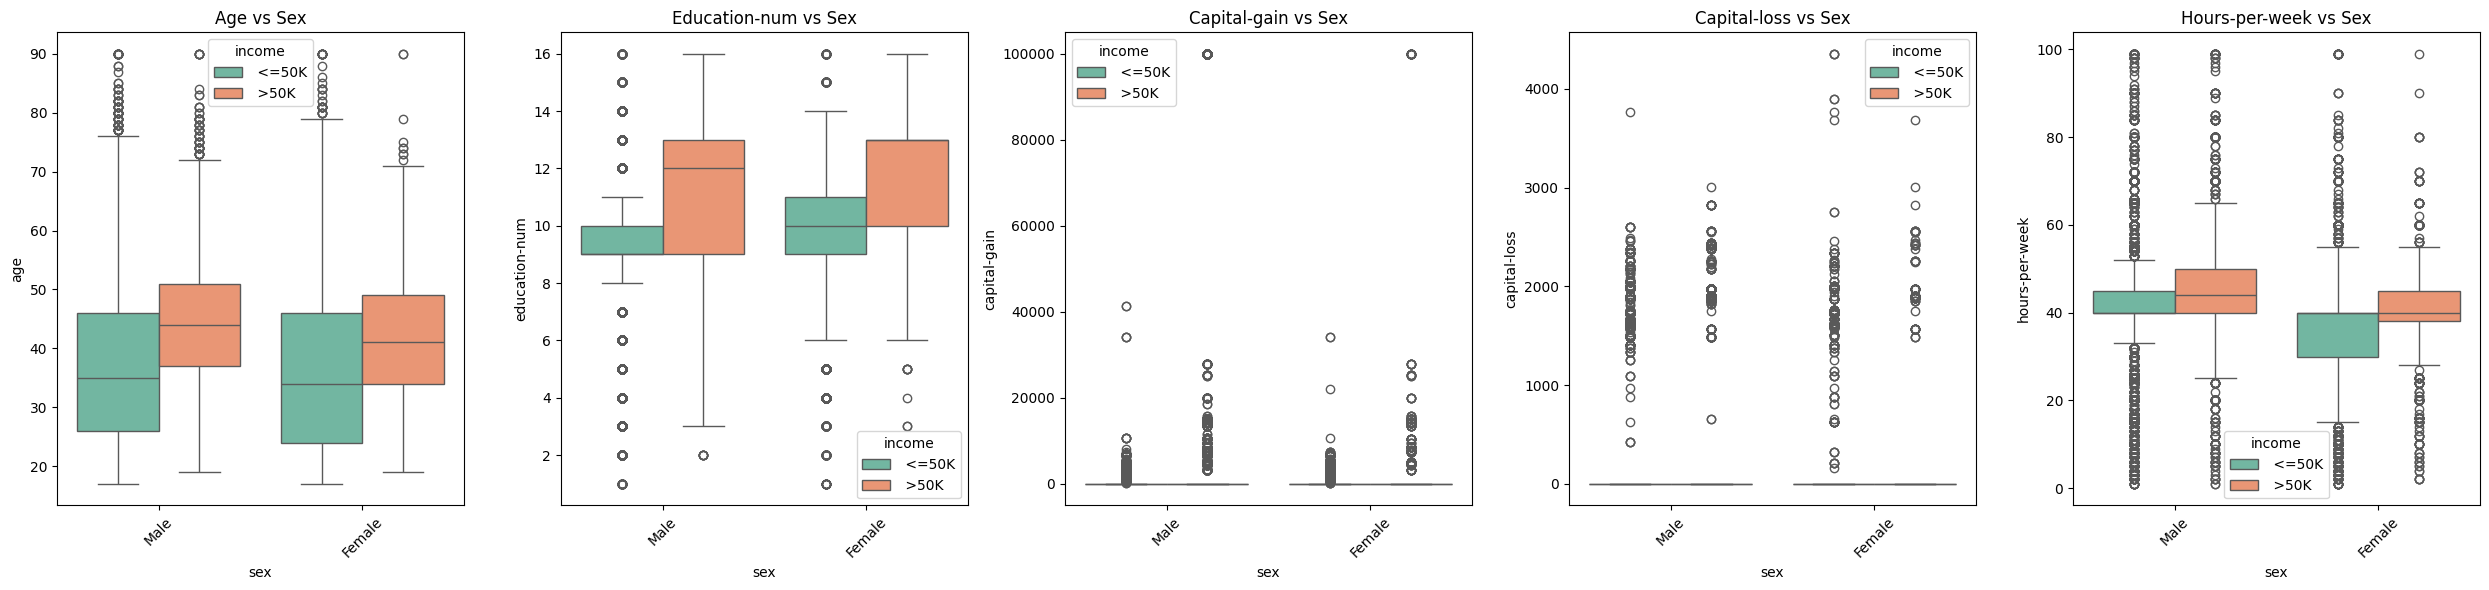


--- Analisando Variáveis Numéricas para a Categoria: RACE ---


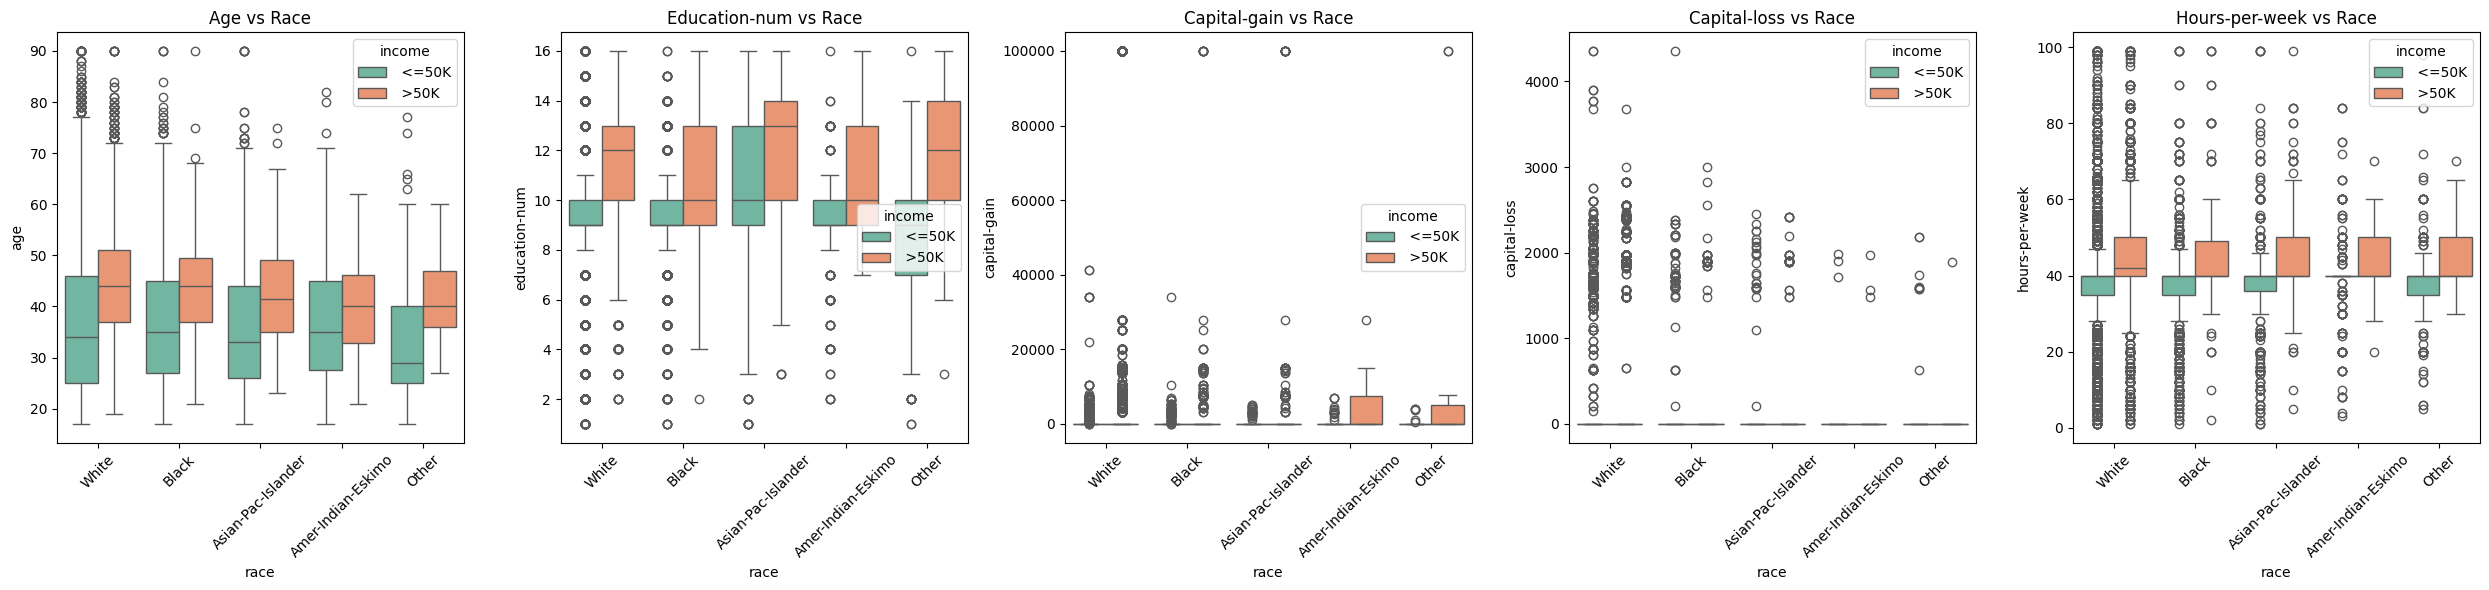


--- Analisando Variáveis Numéricas para a Categoria: WORKCLASS ---


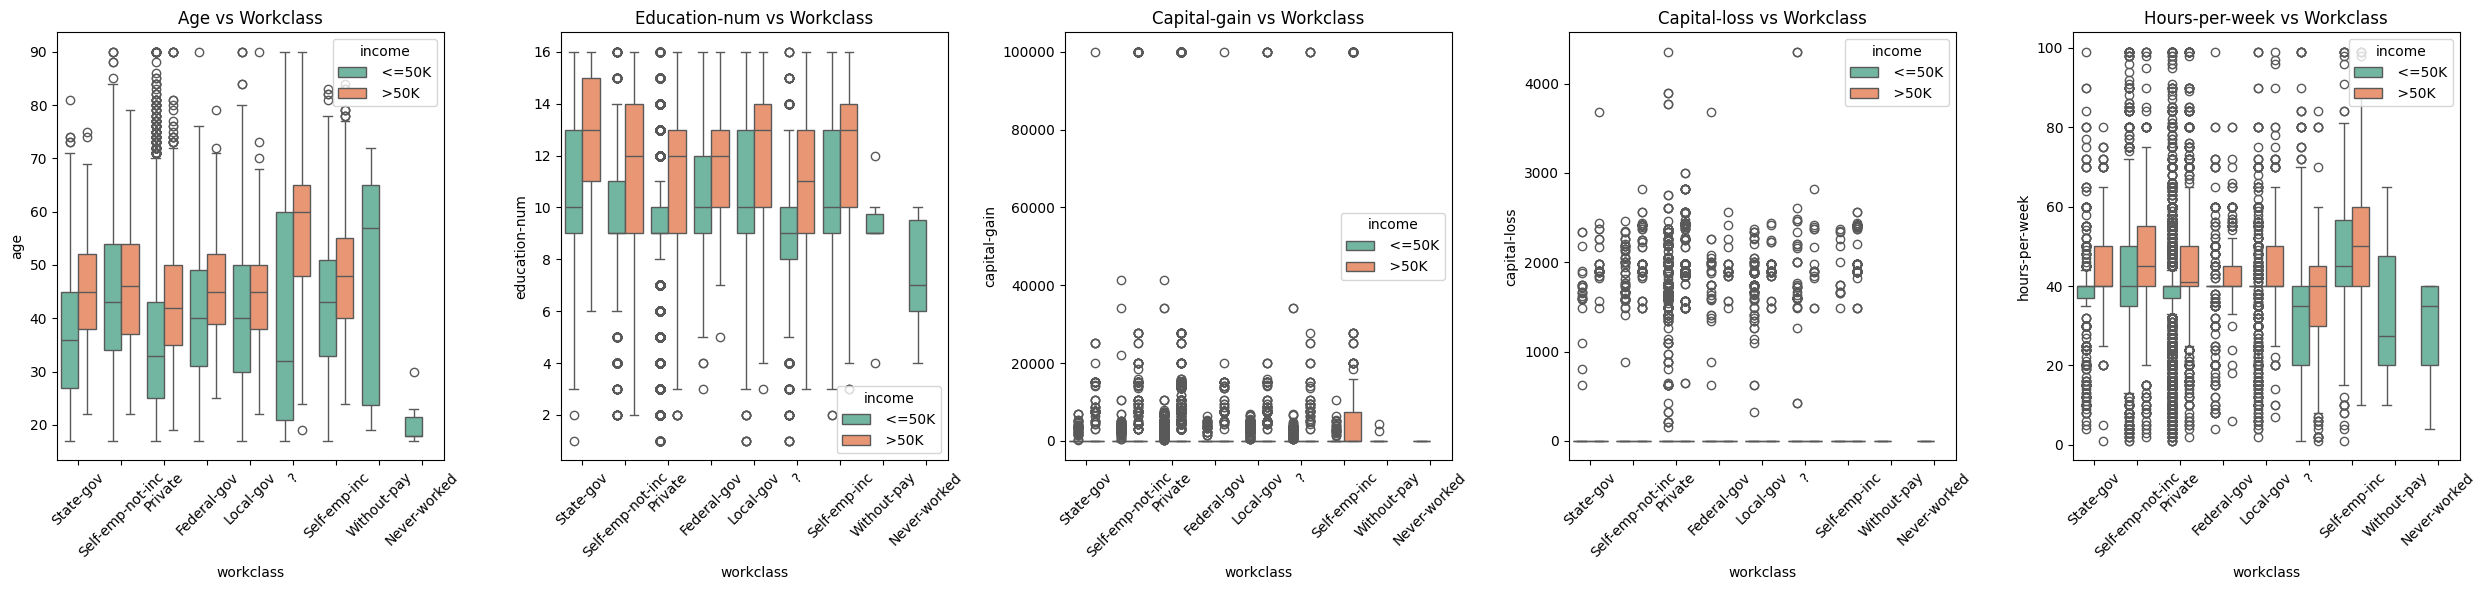


--- Analisando Variáveis Numéricas para a Categoria: RELATIONSHIP ---


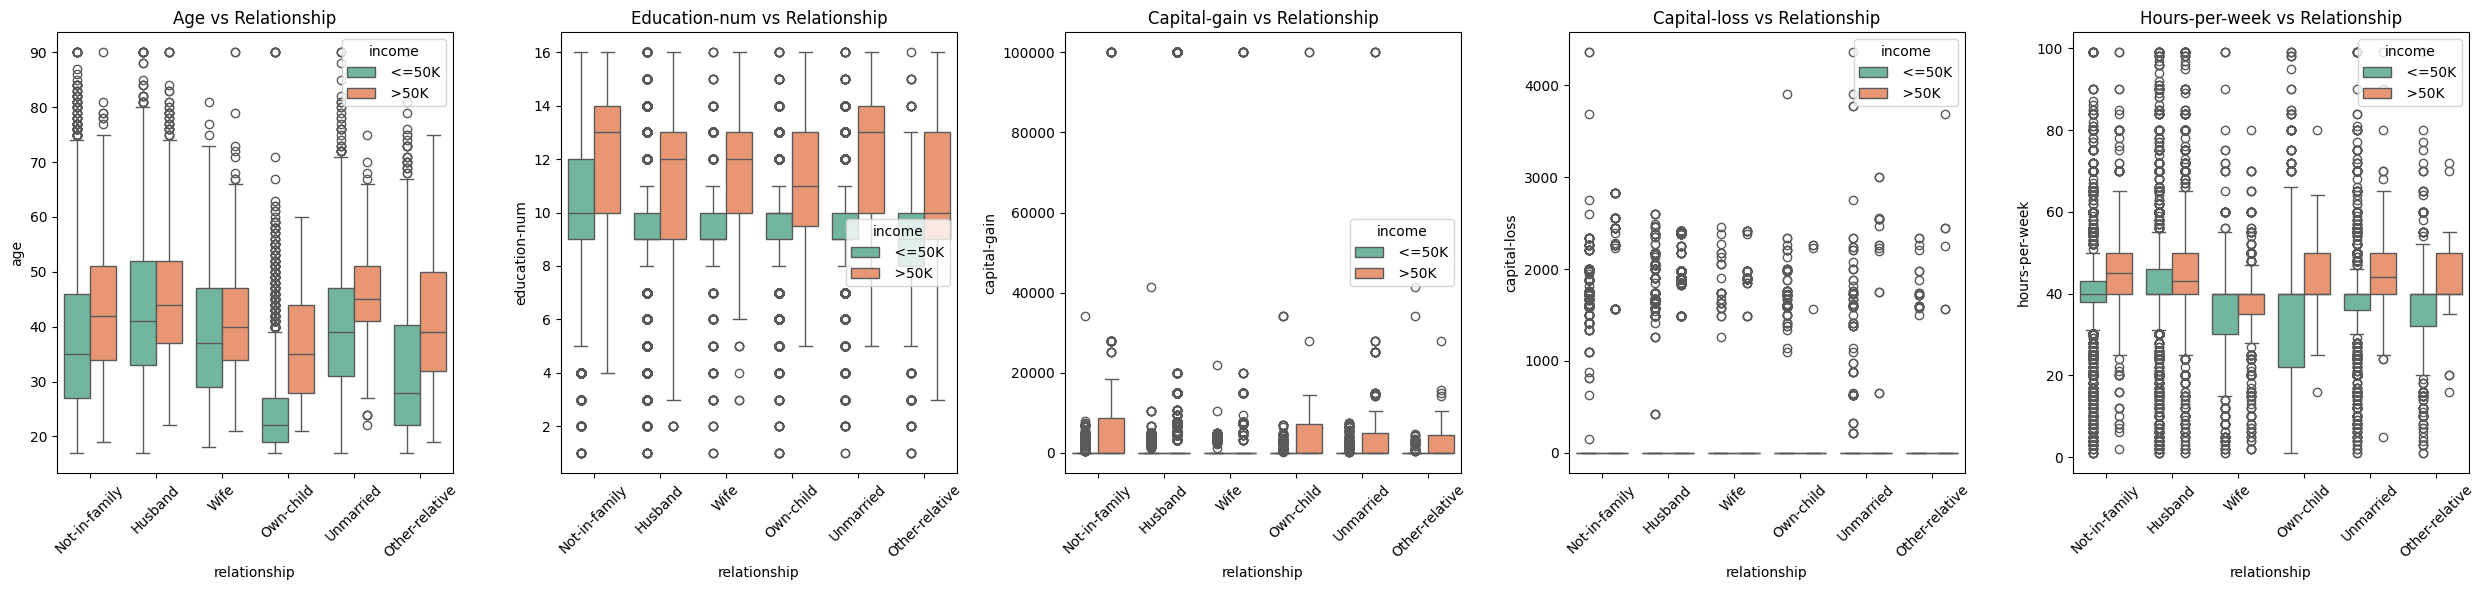

In [54]:
# 1. Identificando colunas (removendo fnlwgt pois o peso não costuma ser intuitivo visualmente)
num_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_features = ['sex', 'race', 'workclass', 'relationship'] # Selecionadas as principais para o relatório

# 2. Loop aninhado para gerar as combinações
for cat in cat_features:
    print(f"\n--- Analisando Variáveis Numéricas para a Categoria: {cat.upper()} ---")
    
    # Criamos uma linha de gráficos para cada categoria contendo todas as numéricas
    fig, axes = plt.subplots(1, len(num_features), figsize=(25, 6))
    
    for j, num in enumerate(num_features):
        # Usando Boxplot para ver a distribuição e os outliers
        sns.boxplot(data=df_train, x=cat, y=num, hue='income', ax=axes[j], palette='Set2')
        
        axes[j].set_title(f'{num.capitalize()} vs {cat.capitalize()}')
        axes[j].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()

C:\Users\LKKam\AppData\Local\Temp\ipykernel_24036\1168609385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='income', y='age', palette='Set2')
C:\Users\LKKam\AppData\Local\Temp\ipykernel_24036\1168609385.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_train, x='income', y='hours-per-week', palette='Set3')


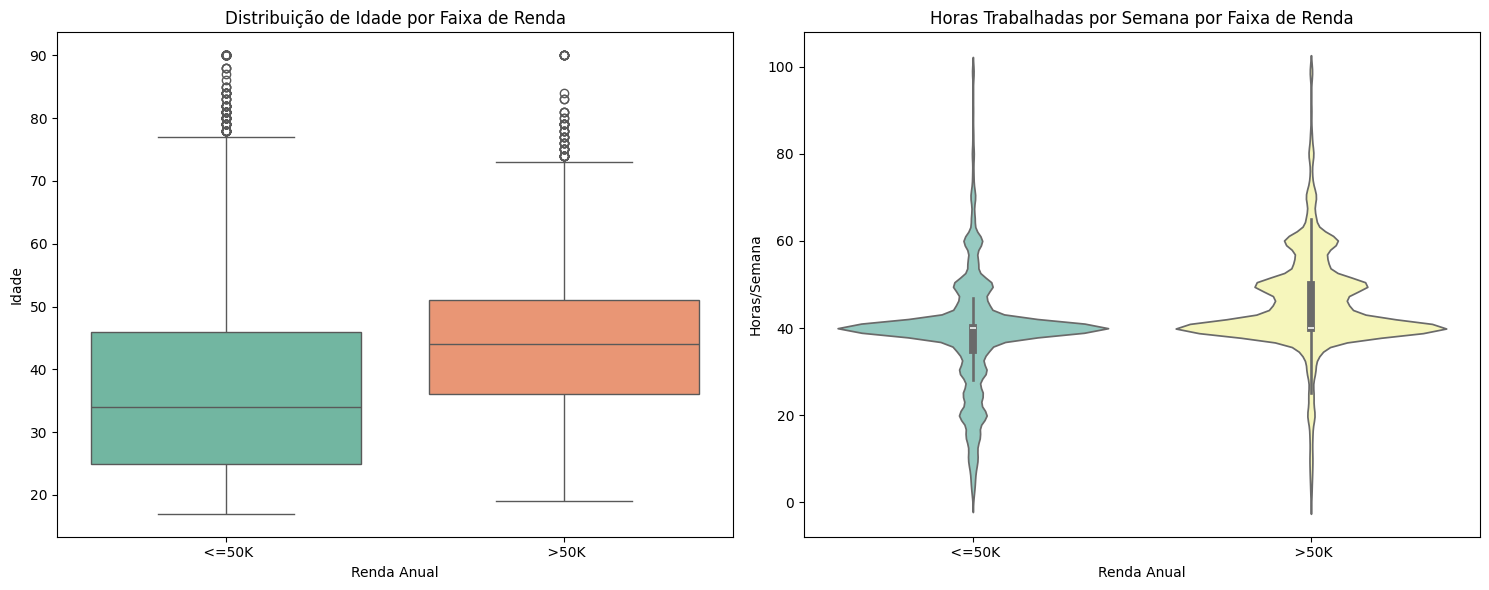

In [46]:
# Comparando Idade e Horas de Trabalho com o Target 'income'
plt.figure(figsize=(15, 6))

# Subplot 1: Idade por Renda (Boxplot)
plt.subplot(1, 2, 1)
sns.boxplot(data=df_train, x='income', y='age', palette='Set2')
plt.title('Distribuição de Idade por Faixa de Renda')
plt.xlabel('Renda Anual')
plt.ylabel('Idade')

# Subplot 2: Horas por Semana por Renda (Violin Plot)
plt.subplot(1, 2, 2)
sns.violinplot(data=df_train, x='income', y='hours-per-week', palette='Set3')
plt.title('Horas Trabalhadas por Semana por Faixa de Renda')
plt.xlabel('Renda Anual')
plt.ylabel('Horas/Semana')

plt.tight_layout()
plt.show()